In [2]:
from Bio import SeqIO
import pandas as pd
import csv

def avg(l):
    t = 0
    for i in l:
        t += i
    return t/len(l)

with open('fasta/c_start_seq_ol.fasta', 'r') as seq_ol:
    aligned_seqs = list(SeqIO.parse(seq_ol, 'fasta'))

aligned_seqs_dict = {}
for seq in aligned_seqs:
    #print(seq.id)
    aligned_seqs_dict[seq.id] = str(seq.seq)

binned_data_seqs = {'id':[], 'category':[], 'aligned_seq':[], 'size':[]}

with open('csv/condensation_starter_train.csv') as binned_data:
    reader = csv.reader(binned_data, delimiter=',')
    for row in reader:
        if row[1] in ['AR', 'SCFA', 'MCFA', 'LCFA']:
            binned_data_seqs['id'].append(row[4])
            binned_data_seqs['category'].append(row[1])
            binned_data_seqs['size'].append(row[2])
            binned_data_seqs['aligned_seq'].append(aligned_seqs_dict[row[4]])
            #print(aligned_seqs_dict[row[2]][358],aligned_seqs_dict[row[2]][359])

df = pd.DataFrame(binned_data_seqs)
df['category_simple'] = df['category'].apply(lambda x:x[-2:])

aa_properties_ref = {}
properties_list = []
with open('properties/15_aa_properties.csv', 'r') as aa_properties_file:
    reader = csv.DictReader(aa_properties_file, delimiter=',')
    for row in reader:
        aa_properties_ref[row["AA_ABREV"]] = {}
        for aa_property in row:
            if aa_property != "AA_ABREV":
                aa_properties_ref[row["AA_ABREV"]][aa_property] = float(row[aa_property])
                if not aa_property in properties_list:
                    properties_list.append(aa_property)

aa_properties = {
    'WOLS870101': True,
    'WOLS870102': 1,
    'WOLS870103': True,
    'FAUJ880109': False,
    'GRAR740102': 1,
    'RADA880108': 1,
    'ZIMJ680103': False,
    'TSAJ990101': False,
    'CHOP780201': 0,
    'CHOP780202': 0,
    'CHOP780203': 0,
    'ZIMJ680104': False,
    'NEU1': False,
    'NEU2': False,
    'NEU3': False
}

#aa_positions = [750,773,161,555,548,123,134,710,150,769,821,227]
aa_positions = [121,122,123,355,356,357,362,363,364,365,357,641,643,730,732,766,768,769,770,783,791] #6Å active site
aa_positions = [121, 123, 355, 730, 732, 734, 769, 360,361,362,363,364,365,766,767, 555,750,821]
#aa_positions = [750,773,161,555,548,123,134,710,150,769,821,227, 121, 355, 730, 732, 734, 769, 360,361,362,363,364,365,766,767]

# for posi in aa_positions:
#     print(aligned_seqs_dict['COND0001758-RBRH_RS12370'][posi])

ml_df = df.copy()
for aa_property in aa_properties:
    #if aa_properties[aa_property]:
    if True:
        # print(aa_property)
        for pos in aa_positions:
            ml_df[aa_property + '_' + str(pos)] = df['aligned_seq'].apply(lambda x:aa_properties_ref[x[pos]][aa_property])
            ml_df = ml_df.copy()

ml_df = ml_df[ml_df['category'] != '']
# print(ml_df['category_simple'].value_counts())

aa_analysis_df = df.copy()
for aa_property in aa_properties:
    if aa_properties[aa_property] != []:
        for pos in aa_positions:
            aa_analysis_df[str(pos)] = df['aligned_seq'].apply(lambda x:x[pos])
            aa_analysis_df = aa_analysis_df.copy()

# print(aa_analysis_df[aa_analysis_df['category'] != 'AR']['121'].value_counts())
# print(aa_analysis_df[aa_analysis_df['category'] != 'AR']['123'].value_counts())
# print(aa_analysis_df[aa_analysis_df['category'] != 'AR']['732'].value_counts())


# print(aa_analysis_df[aa_analysis_df['category'] == 'AR']['121'].value_counts())
# print(aa_analysis_df[aa_analysis_df['category'] == 'AR']['123'].value_counts())
# print(aa_analysis_df[aa_analysis_df['category'] == 'AR']['732'].value_counts())

In [5]:
from Bio import SeqIO
import pandas as pd
import csv

def avg(l):
    t = 0
    for i in l:
        t += i
    return t/len(l)

with open('fasta/c_start_seq_ol.fasta', 'r') as seq_ol:
    aligned_seqs = list(SeqIO.parse(seq_ol, 'fasta'))

aligned_seqs_dict = {}
for seq in aligned_seqs:
    aligned_seqs_dict[seq.id] = str(seq.seq)

binned_data_seqs = {'id':[], 'category':[], 'aligned_seq':[], 'size':[]}

with open('csv/condensation_starter_test.csv') as binned_data:
    reader = csv.reader(binned_data, delimiter=',')
    for row in reader:
        if row[1] in ['AR', 'SCFA', 'MCFA', 'LCFA']:
            binned_data_seqs['id'].append(row[4])
            binned_data_seqs['category'].append(row[1])
            binned_data_seqs['size'].append(row[2])
            binned_data_seqs['aligned_seq'].append(aligned_seqs_dict[row[4]])
            #print(aligned_seqs_dict[row[2]][358],aligned_seqs_dict[row[2]][359])

df_test = pd.DataFrame(binned_data_seqs)
df_test['category_simple'] = df_test['category'].apply(lambda x:x[-2:])

aa_properties_ref = {}
properties_list = []
with open('properties/15_aa_properties.csv', 'r') as aa_properties_file:
    reader = csv.DictReader(aa_properties_file, delimiter=',')
    for row in reader:
        aa_properties_ref[row["AA_ABREV"]] = {}
        for aa_property in row:
            if aa_property != "AA_ABREV":
                aa_properties_ref[row["AA_ABREV"]][aa_property] = row[aa_property]
                if not aa_property in properties_list:
                    properties_list.append(aa_property)

ml_df_test = df_test.copy()
for aa_property in aa_properties:
    #if aa_properties[aa_property]:
    if True:
        # print(aa_property)
        for pos in aa_positions:
            ml_df_test[aa_property + '_' + str(pos)] = df_test['aligned_seq'].apply(lambda x:aa_properties_ref[x[pos]][aa_property])
            ml_df_test = ml_df_test.copy()

ml_df_test = ml_df_test[ml_df_test['category'] != '']
# print(ml_df_test['category_simple'].value_counts())

#### Full dataset

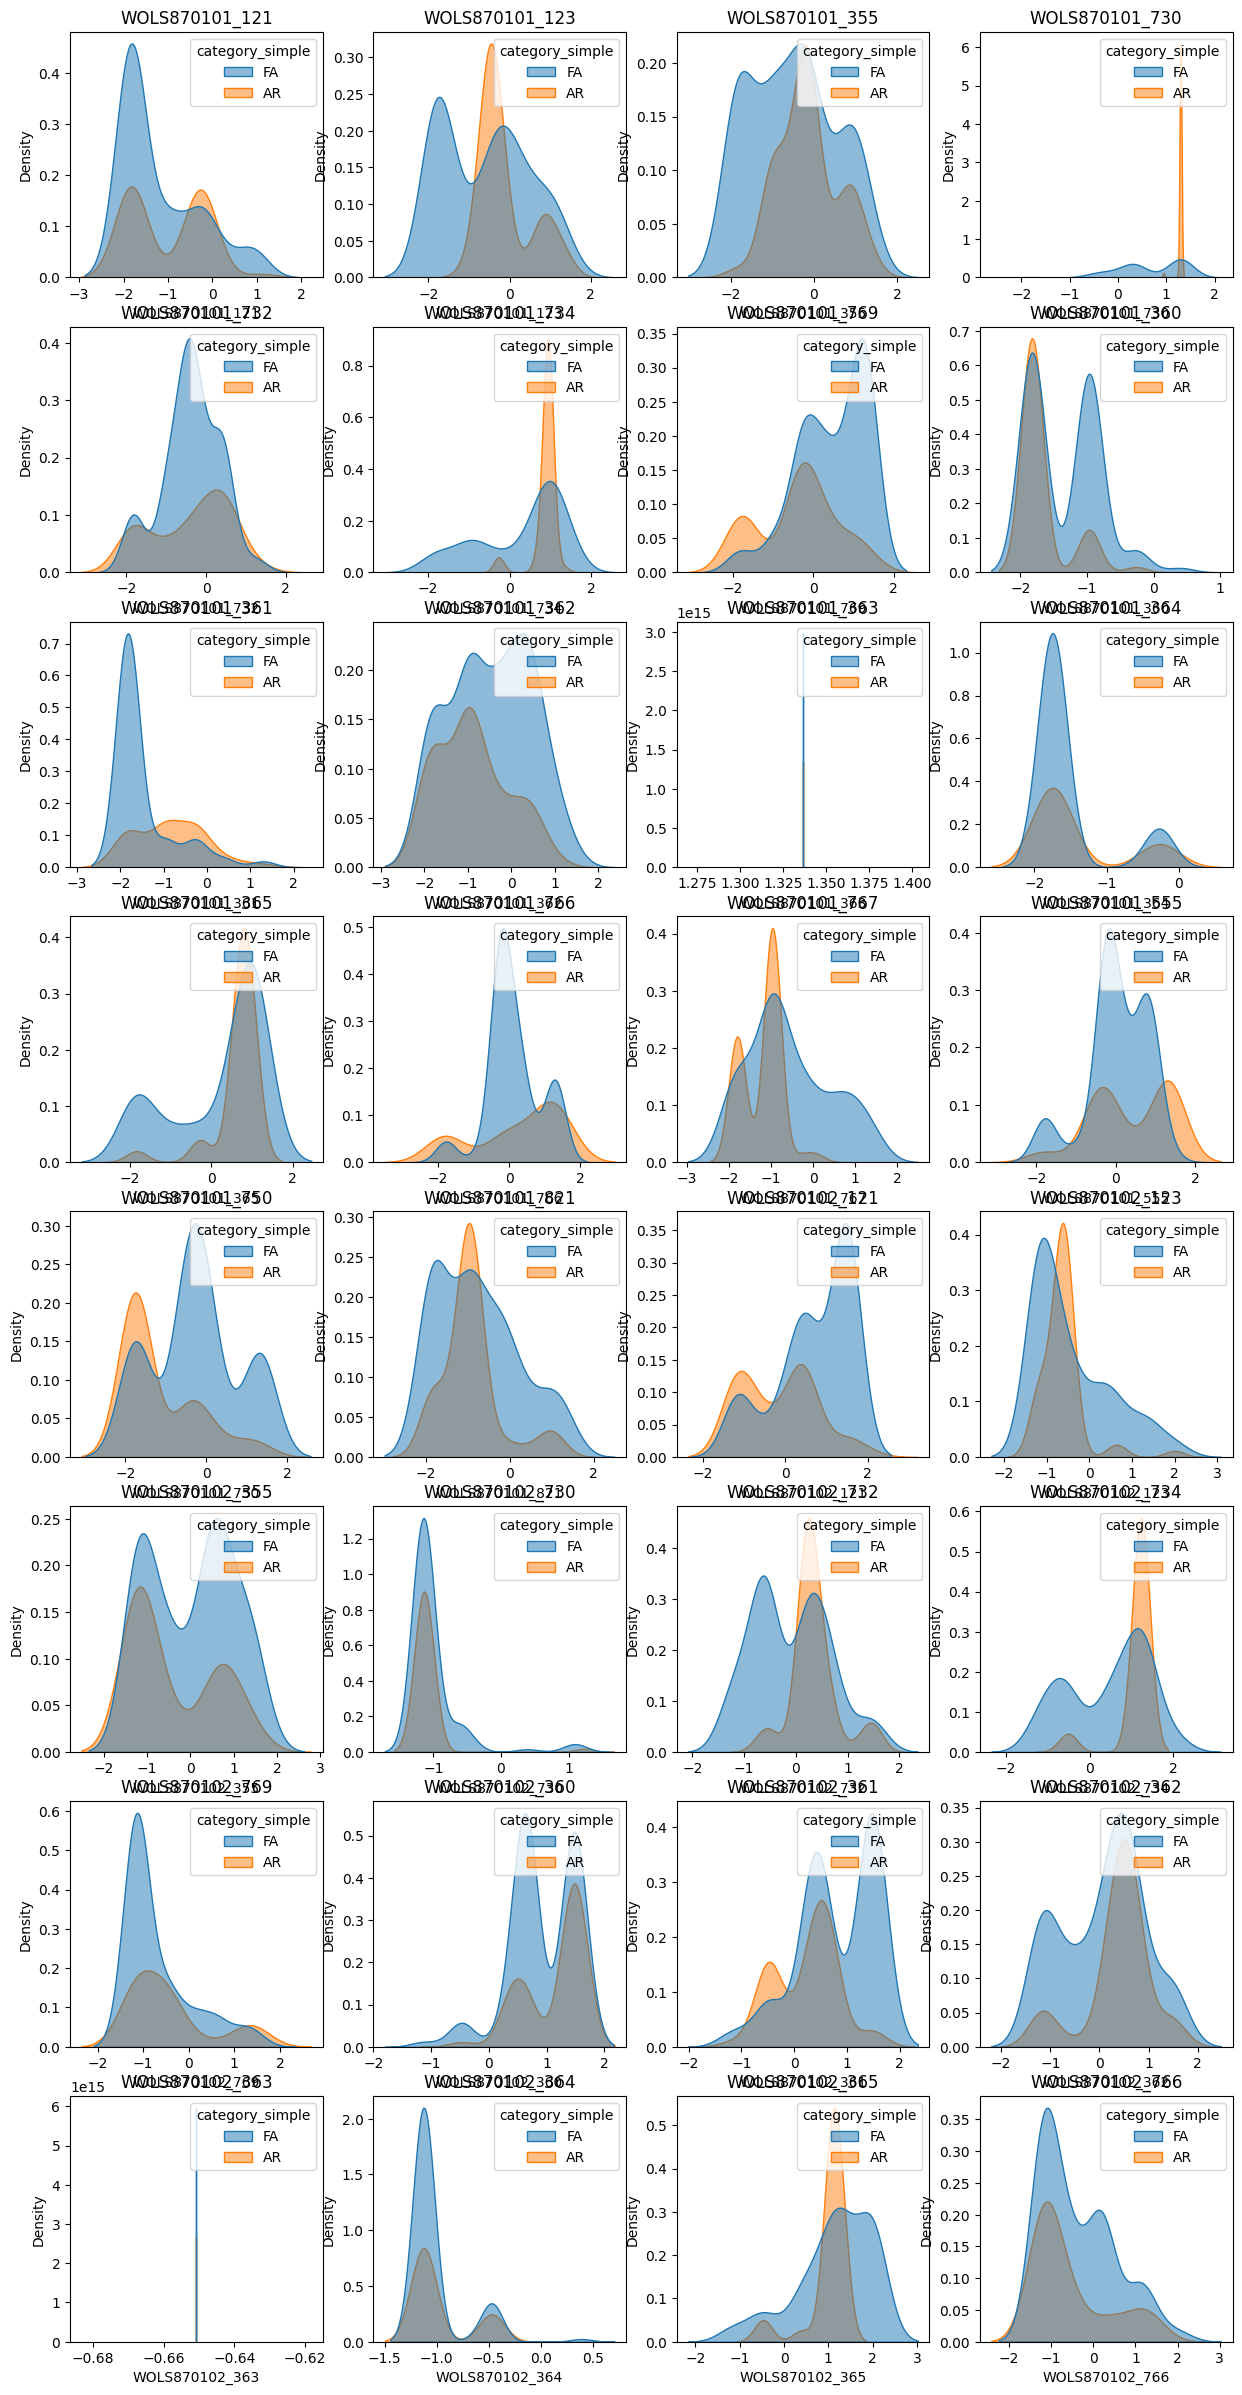

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df = ml_df.drop(['id', 'category', 'aligned_seq', 'size'], axis=1)


numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Set up a reasonably sized figure
plt.figure(figsize=(15, 30))

# Plot KDE for each numeric feature, colored by category
for i, column in enumerate(numeric_columns[:32]):  # Limit to first 10 features for example
    plt.subplot(8, 4, i+1)  # Adjust grid size based on how many features you want to display
    sns.kdeplot(data=df, x=column, hue="category_simple", fill=True, alpha=0.5)
    plt.title(column)
    # plt.tight_layout()

plt.show()

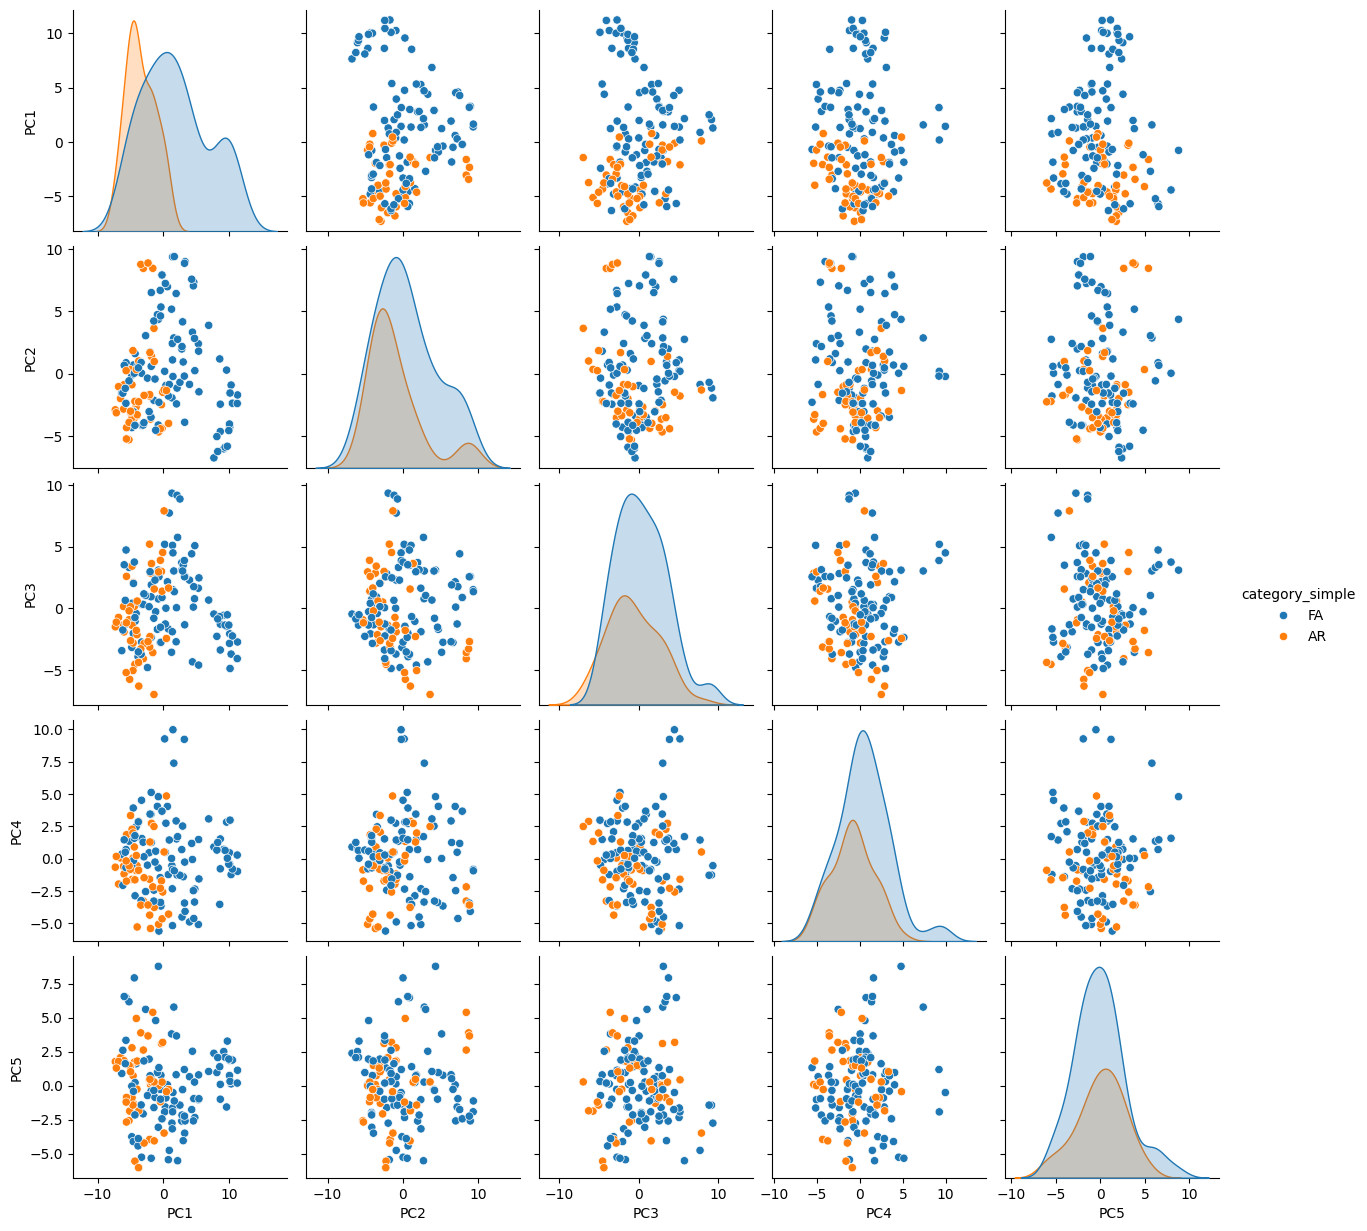

In [7]:
from sklearn.decomposition import PCA

X = df.select_dtypes(include=['float64', 'int64'])

# Apply PCA
pca = PCA(n_components=5)
components = pca.fit_transform(X)
pca_df = pd.DataFrame(components, columns=[f'PC{i+1}' for i in range(5)])
pca_df['category_simple'] = df['category_simple'].values

sns.pairplot(pca_df, hue='category_simple')
#sns.pairplot(df[["WOLS870101_121", "WOLS870101_123", "WOLS870101_355", "WOLS870101_730", "category_simple"]], hue="category_simple")

In [8]:
ml_df_full = pd.concat([ml_df, ml_df_test], ignore_index=True)
#ml_df_full



# Random Forest

[0.90625    0.93548387 0.96774194 0.96774194 0.93548387] avg: 0.9425403225806452


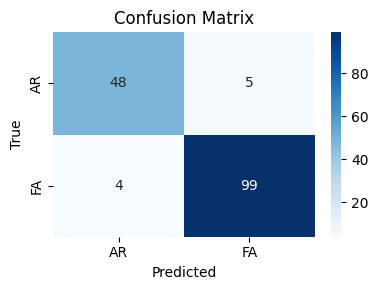


training accuracy :  [0.96774194 0.968      0.968      0.96       0.968     ] avg: 0.9663483870967742
test accuracy :  [0.90625    0.93548387 0.96774194 0.96774194 0.93548387] avg: 0.9425403225806452

misclassified: 
                          id category
15   COND0002048-RBRH_03867       AR
51   COND0002581-QKF54435.2     SCFA
56        COND0001297-cal17       AR
91   COND0001574-ATY72525.1     SCFA
101  COND0002377-QBA57735.1       AR
124        COND0001437-obaI       AR
129    COND0001599-I35_4189     MCFA
142        COND0002125-frsA     SCFA
149   COND0001825-XNC2_2611       AR


/var/folders/rt/kl_lws993wvbgr3lkh7w2g8r0000gn/T/ipykernel_58307/2958634279.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  misclassified = ml_df[y != cvs_pred]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle

i = 1

y = ml_df['category_simple']
X = ml_df.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)
X, y = shuffle(X, y,random_state=i)

rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.015,max_depth=5,min_samples_leaf=3,max_leaf_nodes=6,min_samples_split=5,n_estimators=100,max_features="log2", random_state=i)

cvs = cross_val_score(rf_model_cv, X, y, cv=5)
print(cvs, 'avg:',  avg(cvs))
cvs_pred = cross_val_predict(rf_model_cv, X, y, cv=5)
cvoutput = cross_validate(rf_model_cv, X, y, cv=5, return_train_score=True)

# print(confusion_matrix(y, cvs_pred, labels=["AR", "FA"]))
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y, cvs_pred, labels=["AR", "FA"]), annot=True, fmt='d', cmap='Blues', xticklabels=['AR', 'FA'], yticklabels=['AR', 'FA'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

misclassified = ml_df[y != cvs_pred]
# print('\nmisclassified: \n',misclassified.iloc[:,:2])


#### test set

test set confusion matrix: 


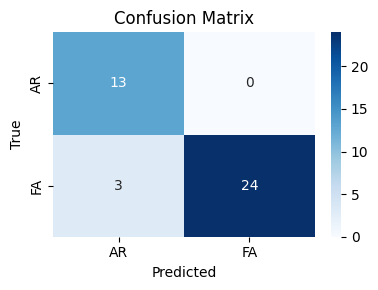

test set :
0.925


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.utils import shuffle


i = 1

y = ml_df['category_simple']
X = ml_df.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)
X, y = shuffle(X, y,random_state=i)

y_test = ml_df_test['category_simple']
X_test = ml_df_test.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)

rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.015,max_depth=10,min_samples_leaf=1,max_leaf_nodes=4,n_estimators=100,min_samples_split=3, max_features="log2", random_state=i)
rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.015,max_depth=5,min_samples_leaf=3,max_leaf_nodes=6,min_samples_split=5,n_estimators=100,max_features="log2", random_state=i)

cvs = cross_val_score(rf_model_cv, X, y, cv=5)
# print(cvs, 'avg:',  avg(cvs))
cvs_pred = cross_val_predict(rf_model_cv, X, y, cv=5)
cvoutput = cross_validate(rf_model_cv, X, y, cv=5, return_train_score=True)
# print(confusion_matrix(y, cvs_pred, labels=["AR", "FA"]))
# print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
# print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

#misclassified = ml_df[y != cvs_pred]
#print(misclassified.iloc[:,:2])

rf_model_cv.fit(X,y)

pred = rf_model_cv.predict(X_test)
print('test set confusion matrix: ')
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, pred, labels=["AR", "FA"]), annot=True, fmt='d', cmap='Blues', xticklabels=['AR', 'FA'], yticklabels=['AR', 'FA'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print('test set :')
print(accuracy_score(y_test, pred))

#rf_model_cv.feature_importances_




#### full dataset


[0.875      1.         0.92307692 0.97435897 0.8974359 ] avg: 0.9339743589743591


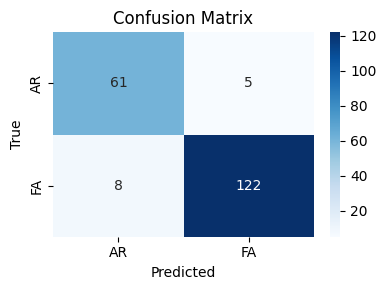


training accuracy :  [0.95512821 0.96815287 0.98089172 0.98089172 0.96815287] avg: 0.9706434754205455
test accuracy :  [0.875      1.         0.92307692 0.97435897 0.8974359 ] avg: 0.9339743589743591

Misclassified:
                           id category
47       COND0002680-CV_2233       AR
51    COND0002581-QKF54435.2     SCFA
56         COND0001297-cal17       AR
84          COND0002424-sacE     LCFA
91    COND0001574-ATY72525.1     SCFA
124         COND0001437-obaI       AR
129     COND0001599-I35_4189     MCFA
142         COND0002125-frsA     SCFA
146         COND0002373-bnvO       AR
149    COND0001825-XNC2_2611       AR
165         COND0002125-frsD     SCFA
172  COND0002359-FM076_21195     MCFA
179         COND0001414-griA     SCFA


/var/folders/rt/kl_lws993wvbgr3lkh7w2g8r0000gn/T/ipykernel_58307/3167146046.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  misclassified = ml_df_full[y != cvs_pred]


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle

i = 1

y = ml_df_full['category_simple']
X = ml_df_full.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)
X, y = shuffle(X, y,random_state=i)

rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.015,max_depth=10,min_samples_leaf=1,max_leaf_nodes=5,n_estimators=100,min_samples_split=3, max_features="log2", random_state=i)
rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.015,max_depth=5,min_samples_leaf=3,max_leaf_nodes=6,min_samples_split=5,n_estimators=100,max_features="log2", random_state=i)

cvs = cross_val_score(rf_model_cv, X, y, cv=5)
print(cvs, 'avg:',  avg(cvs))
cvs_pred = cross_val_predict(rf_model_cv, X, y, cv=5)
cvoutput = cross_validate(rf_model_cv, X, y, cv=5, return_train_score=True)

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y, cvs_pred, labels=["AR", "FA"]), annot=True, fmt='d', cmap='Blues', xticklabels=['AR', 'FA'], yticklabels=['AR', 'FA'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

misclassified = ml_df_full[y != cvs_pred]
print('\nMisclassified:\n',misclassified.iloc[:,:2])


### stdev

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix,accuracy_score, balanced_accuracy_score
from sklearn.utils import shuffle
import pandas as pd


df_tax = pd.read_csv('csv/condensation_starter.csv')


i = 1

# y = ml_df_full['category_simple']
# X = ml_df_full.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)

with open('test_accuracies_full_aromaticity.csv', 'w') as f:
    for i in range(0,200):
        print(i)
        y = ml_df_full['category_simple']
        X = ml_df_full.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)
        X, y = shuffle(X, y,random_state=i)

        
        rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.015,max_depth=5,min_samples_leaf=3,max_leaf_nodes=6,min_samples_split=5,n_estimators=100,max_features="log2", random_state=i)

        cvs = cross_val_score(rf_model_cv, X, y, cv=5)
        print(cvs, 'avg:',  avg(cvs))

        #print(y[ml_df_full['tax_cat'] == 'streptomyces'])
        cvs_pred = cross_val_predict(rf_model_cv, X, y, cv=5)
        cvoutput = cross_validate(rf_model_cv, X, y, cv=5, return_train_score=True)
        print(confusion_matrix(y, cvs_pred, labels=['AR', 'FA']))
        # Confusion matrix for 'streptomyces' category
        
        #print(y, cvs_pred)

        trues = []
        preds = []
        c = 0
        # for index, value in y.items():
        #     #print(index,value, cvs_pred[c])
        #     if ml_df_full.at[index, 'tax_cat'] == 'streptomyces':
        #         trues.append(value)
        #         preds.append(cvs_pred[c])
        #     c += 1
        #     #print(y[i], cvs_pred[i])
        # cm = confusion_matrix(trues, preds, labels=['AR', 'FA'])
        # print('filtered_confusion:\n',cm)
        # print('acc', (cm[0][0] + cm[1][1])/(cm[0][0] + cm[1][1] +cm[0][1] + cm[1][0]))

        
        print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))

        print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))
        for testscore in cvoutput['test_score']:
            f.write(str(testscore) + '\n' )


rf_model_cv.fit(X,y)

pred = rf_model_cv.predict(X_test)
print('test set confusion matrix: ')
print(confusion_matrix(y_test, pred, labels=['AR', 'FA']))
print('test set :')
print(accuracy_score(y_test, pred))
print(balanced_accuracy_score(y_test, pred))

0
[0.925      0.94871795 0.8974359  0.92307692 0.92307692] avg: 0.9234615384615384
[[ 58   8]
 [  7 123]]

training accuracy :  [0.96153846 0.96815287 0.98089172 0.97452229 0.97452229] avg: 0.9719255267025968
test accuracy :  [0.925      0.94871795 0.8974359  0.92307692 0.92307692] avg: 0.9234615384615384
1
[0.875      1.         0.92307692 0.97435897 0.8974359 ] avg: 0.9339743589743591
[[ 61   5]
 [  8 122]]

training accuracy :  [0.95512821 0.96815287 0.98089172 0.98089172 0.96815287] avg: 0.9706434754205455
test accuracy :  [0.875      1.         0.92307692 0.97435897 0.8974359 ] avg: 0.9339743589743591
2
[0.975      0.97435897 0.92307692 0.8974359  0.87179487] avg: 0.9283333333333333
[[ 59   7]
 [  7 123]]

training accuracy :  [0.96794872 0.97452229 0.96815287 0.98726115 0.98089172] avg: 0.9757553486852849
test accuracy :  [0.975      0.97435897 0.92307692 0.8974359  0.87179487] avg: 0.9283333333333333
3
[0.95       0.97435897 0.87179487 0.92307692 0.92307692] avg: 0.9284615384615

ValueError: At least one label specified must be in y_true

#### feature importances and saving model

In [14]:
from sklearn.ensemble import RandomForestClassifier
import pickle

y = ml_df_full['category_simple']
X = ml_df_full.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)

rf_model = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.015,max_depth=5,min_samples_leaf=3,max_leaf_nodes=6,min_samples_split=5,n_estimators=100,max_features="log2", random_state=0)

rf_model.fit(X,y)
with open('AR_FA.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

importances = rf_model.feature_importances_


columns = X.columns

aa_percentage = {}
features_type_importance = {}
for k in range(len(columns)):
    #print(int(columns[i][-1]))
    #print(columns[k].split('_')[-1], round(importances[k], 8))
    if not int(columns[k].split('_')[-1]) in aa_percentage:
        aa_percentage[int(columns[k].split('_')[-1])] = 0
    aa_percentage[int(columns[k].split('_')[-1])] += round(importances[k], 8)
    if not columns[k].split('_')[0] in features_type_importance:
        features_type_importance[columns[k].split('_')[0]] = 0
    features_type_importance[columns[k].split('_')[0]] += round(importances[k], 8)
print(aa_percentage)
print(features_type_importance)

l = []
for position in aa_percentage:
    l.append([position, aa_percentage[position]])
sorted(l, key=lambda x:x[1], reverse=True)

{121: 0.12962623, 123: 0.25875551999999996, 355: 0.01930954, 730: 0.06532703000000001, 732: 0.015184849999999998, 734: 0.05879808, 769: 0.06139546, 360: 0.01503485, 361: 0.020619770000000003, 362: 0.01280947, 363: 0.0, 364: 0.00290292, 365: 0.033966680000000006, 766: 0.02434877, 767: 0.01806922, 555: 0.18373201, 750: 0.03359088, 821: 0.04652875}
{'WOLS870101': 0.07563469, 'WOLS870102': 0.03581313, 'WOLS870103': 0.12281087, 'FAUJ880109': 0.09028823, 'GRAR740102': 0.03384935, 'RADA880108': 0.023395950000000002, 'ZIMJ680103': 0.04362484, 'TSAJ990101': 0.04833976, 'CHOP780201': 0.04314803999999999, 'CHOP780202': 0.10174662000000001, 'CHOP780203': 0.07617554, 'ZIMJ680104': 0.06162174000000001, 'NEU1': 0.11482922, 'NEU2': 0.06526809000000001, 'NEU3': 0.06345396}


[[123, 0.25875551999999996],
 [555, 0.18373201],
 [121, 0.12962623],
 [730, 0.06532703000000001],
 [769, 0.06139546],
 [734, 0.05879808],
 [821, 0.04652875],
 [365, 0.033966680000000006],
 [750, 0.03359088],
 [766, 0.02434877],
 [361, 0.020619770000000003],
 [355, 0.01930954],
 [767, 0.01806922],
 [732, 0.015184849999999998],
 [360, 0.01503485],
 [362, 0.01280947],
 [364, 0.00290292],
 [363, 0.0]]

# SVM

[0.875      0.87096774 0.90322581 0.90322581 0.93548387] 0.8975806451612904


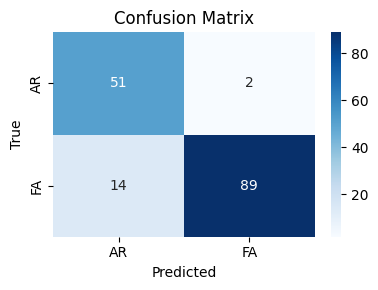


training accuracy :  [0.95967742 0.944      0.952      0.952      0.96      ] avg: 0.9535354838709678
test accuracy :  [0.875      0.87096774 0.90322581 0.90322581 0.93548387] avg: 0.8975806451612904

Misclassified:
                            id category
17     COND0000439-AHH53506.1     MCFA
23     COND0000306-SSIG_07966     LCFA
51     COND0002581-QKF54435.2     SCFA
55           COND0001230-sln9     MCFA
67           COND0001657-lesA     MCFA
69          COND0002661-tsk10     SCFA
91     COND0001574-ATY72525.1     SCFA
97        COND0001370-cda2PSI     SCFA
100  COND0001844-RBRH_RS16800     MCFA
104          COND0002050-necA     SCFA
117    COND0002654-UHJ79953.1     LCFA
129      COND0001599-I35_4189     MCFA
135   COND0002467-YWY_RS21605     SCFA
142          COND0002125-frsA     SCFA
149     COND0001825-XNC2_2611       AR
152      COND0000460-VV2_0844       AR


/var/folders/rt/kl_lws993wvbgr3lkh7w2g8r0000gn/T/ipykernel_58307/2811839179.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  misclassified = ml_df[y != cvs_pred]


In [24]:
from sklearn import svm
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

i = 1
y = ml_df['category_simple']
X = ml_df.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)
X, y = shuffle(X, y,random_state=i)

c = svm.SVC(probability=True,C = 0.75, class_weight='balanced')#, kernel='sigmoid')
cvs = cross_val_score(c, X, y, cv=5)
cvs_pred = cross_val_predict(c, X, y, cv=5)
print(cvs, avg(cvs))

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y, cvs_pred, labels=["AR", "FA"]), annot=True, fmt='d', cmap='Blues', xticklabels=['AR', 'FA'], yticklabels=['AR', 'FA'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

cvoutput = cross_validate(c, X, y, cv=5, return_train_score=True)
print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

misclassified = ml_df[y != cvs_pred]
print('\nMisclassified:\n',misclassified.iloc[:,:2])

test set confusion matrix: 


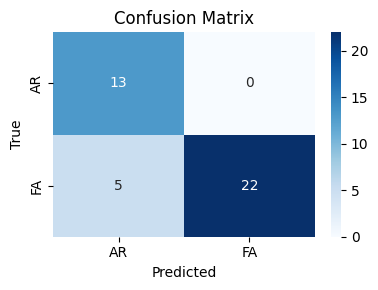

test set :
0.875


In [29]:
from sklearn import svm
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

i = 1

y = ml_df['category_simple']
X = ml_df.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)
X, y = shuffle(X, y,random_state=i)

y_test = ml_df_test['category_simple']
X_test = ml_df_test.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)

c = svm.SVC(probability=True,C = 0.75, class_weight='balanced')

cvs = cross_val_score(rf_model_cv, X, y, cv=5)
# print(cvs, 'avg:',  avg(cvs))
# cvs_pred = cross_val_predict(c, X, y, cv=5)
# cvoutput = cross_validate(c, X, y, cv=5, return_train_score=True)
# plt.figure(figsize=(4, 3))
# sns.heatmap(confusion_matrix(y, cvs_pred, labels=["AR", "FA"]), annot=True, fmt='d', cmap='Blues', xticklabels=['AR', 'FA'], yticklabels=['AR', 'FA'])
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("Confusion Matrix")
# plt.tight_layout()
# plt.show()
# print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
# print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

#misclassified = ml_df[y != cvs_pred]
#print(misclassified.iloc[:,:2])

c.fit(X,y)

pred = c.predict(X_test)
print('test set confusion matrix: ')
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, pred, labels=["AR", "FA"]), annot=True, fmt='d', cmap='Blues', xticklabels=['AR', 'FA'], yticklabels=['AR', 'FA'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
print('test set :')
print(accuracy_score(y_test, pred))

test_pred_decision = c.decision_function(X_test)
# test_pred_decision

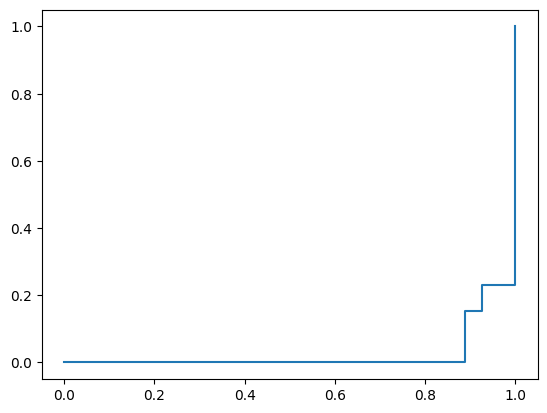

In [49]:
from sklearn.metrics import roc_curve, auc
from matplotlib import pyplot as plt

#ly = list(map(lambda x: int(x.replace('AR', '1').replace('FA', '0')), list(y_test)))


#lc = list(map(lambda x: int(x.replace('AR', '1').replace('FA', '0')), list(test_pred_decision)))

roc_fpr,roc_tpr, threshold = roc_curve(y_test, test_pred_decision, pos_label='AR')
aucout = auc(roc_fpr,roc_tpr)

plt.plot(roc_fpr,roc_tpr)


[0.825      0.97435897 0.87179487 0.87179487 0.8974359 ] 0.888076923076923


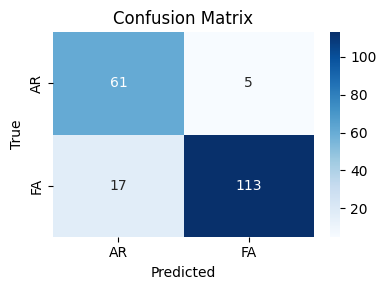


training accuracy :  [0.94871795 0.94904459 0.94267516 0.94904459 0.94904459] avg: 0.9477053731830802
test accuracy :  [0.825      0.97435897 0.87179487 0.87179487 0.8974359 ] avg: 0.888076923076923

Misclassified:
                            id category
11     COND0001036-AGZ15476.1     LCFA
23     COND0000306-SSIG_07966     LCFA
51     COND0002581-QKF54435.2     SCFA
55           COND0001230-sln9     MCFA
56          COND0001297-cal17       AR
69          COND0002661-tsk10     SCFA
84           COND0002424-sacE     LCFA
91     COND0001574-ATY72525.1     SCFA
100  COND0001844-RBRH_RS16800     MCFA
101    COND0002377-QBA57735.1       AR
104          COND0002050-necA     SCFA
129      COND0001599-I35_4189     MCFA
142          COND0002125-frsA     SCFA
143  COND0002638-DMH02_027320     SCFA
146          COND0002373-bnvO       AR
149     COND0001825-XNC2_2611       AR
152      COND0000460-VV2_0844       AR
161  COND0001758-RBRH_RS12370     SCFA
165          COND0002125-frsD     SCFA
174

/var/folders/rt/kl_lws993wvbgr3lkh7w2g8r0000gn/T/ipykernel_58307/2749285560.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  misclassified = ml_df_full[y != cvs_pred]


In [31]:
from sklearn import svm
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

i = 1
y = ml_df_full['category_simple']
X = ml_df_full.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)
X, y = shuffle(X, y,random_state=i)

c = svm.SVC(probability=True,C = 0.6, class_weight='balanced')#, kernel='sigmoid')
cvs = cross_val_score(c, X, y, cv=5)
cvs_pred = cross_val_predict(c, X, y, cv=5)
print(cvs, avg(cvs))
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y, cvs_pred, labels=["AR", "FA"]), annot=True, fmt='d', cmap='Blues', xticklabels=['AR', 'FA'], yticklabels=['AR', 'FA'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
cvoutput = cross_validate(c, X, y, cv=5, return_train_score=True)
print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

misclassified = ml_df_full[y != cvs_pred]
print('\nMisclassified:\n',misclassified.iloc[:,:2])

# Logistic Regression

[0.875      0.93548387 0.93548387 0.90322581 0.90322581] 0.910483870967742


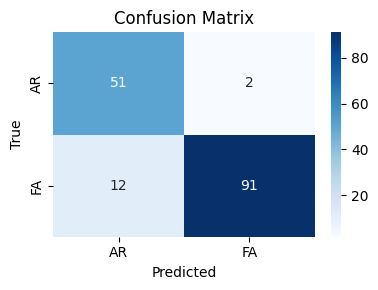


training accuracy :  [0.97580645 0.952      0.968      0.96       0.96      ] avg: 0.9631612903225806
test accuracy :  [0.875      0.93548387 0.93548387 0.90322581 0.90322581] avg: 0.910483870967742

Misclassified:
                            id category
17     COND0000439-AHH53506.1     MCFA
23     COND0000306-SSIG_07966     LCFA
51     COND0002581-QKF54435.2     SCFA
55           COND0001230-sln9     MCFA
67           COND0001657-lesA     MCFA
69          COND0002661-tsk10     SCFA
71     COND0001524-Sulba_0748     MCFA
91     COND0001574-ATY72525.1     SCFA
100  COND0001844-RBRH_RS16800     MCFA
129      COND0001599-I35_4189     MCFA
135   COND0002467-YWY_RS21605     SCFA
142          COND0002125-frsA     SCFA
146          COND0002373-bnvO       AR
152      COND0000460-VV2_0844       AR


/var/folders/rt/kl_lws993wvbgr3lkh7w2g8r0000gn/T/ipykernel_58307/3723391752.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  misclassified = ml_df[y != cvs_pred]


In [33]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, ARDRegression
from sklearn.model_selection import cross_val_predict, cross_val_score
import pandas as pd
from sklearn.metrics import confusion_matrix

i = 1
y = ml_df['category_simple']
X = ml_df.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)
X, y = shuffle(X, y, random_state=i)

lreg = LogisticRegression(solver='liblinear', class_weight='balanced', penalty='l2', C=0.04)

cvs = cross_val_score(lreg, X, y, cv=5)
cvs_pred = cross_val_predict(lreg, X, y, cv=5)
print(cvs, avg(cvs))
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y, cvs_pred, labels=["AR", "FA"]), annot=True, fmt='d', cmap='Blues', xticklabels=['AR', 'FA'], yticklabels=['AR', 'FA'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
cvoutput = cross_validate(lreg, X, y, cv=5, return_train_score=True)
print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

misclassified = ml_df[y != cvs_pred]
print('\nMisclassified:\n',misclassified.iloc[:,:2])

[0.875      0.93548387 0.93548387 0.90322581 0.90322581] avg: 0.910483870967742


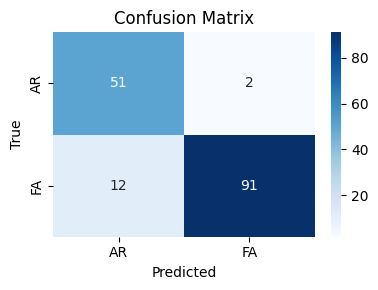


training accuracy :  [0.97580645 0.952      0.968      0.96       0.96      ] avg: 0.9631612903225806
test accuracy :  [0.875      0.93548387 0.93548387 0.90322581 0.90322581] avg: 0.910483870967742
test set confusion matrix: 
test set :
0.875


In [34]:
from sklearn import svm
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

i = 1

y = ml_df['category_simple']
X = ml_df.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)
X, y = shuffle(X, y,random_state=i)

y_test = ml_df_test['category_simple']
X_test = ml_df_test.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)

lreg = LogisticRegression(solver='liblinear', class_weight='balanced', penalty='l2', C=0.04)

cvs = cross_val_score(lreg, X, y, cv=5)
print(cvs, 'avg:',  avg(cvs))
cvs_pred = cross_val_predict(lreg, X, y, cv=5)
cvoutput = cross_validate(lreg, X, y, cv=5, return_train_score=True)
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y, cvs_pred, labels=["AR", "FA"]), annot=True, fmt='d', cmap='Blues', xticklabels=['AR', 'FA'], yticklabels=['AR', 'FA'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

#misclassified = ml_df[y != cvs_pred]
#print(misclassified.iloc[:,:2])

lreg.fit(X,y)

pred = lreg.predict(X_test)
print('test set confusion matrix: ')
confusion_matrix(y_test, pred, labels=["AR", "FA"])
print('test set :')
print(accuracy_score(y_test, pred))

##### logreg full dataset

[0.9        0.92307692 0.87179487 0.92307692 0.92307692] 0.9082051282051283


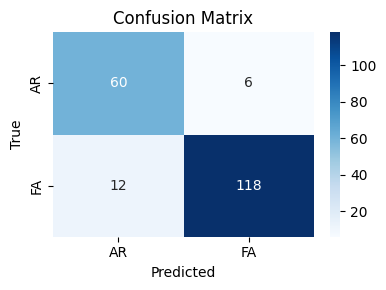


training accuracy :  [0.97435897 0.96815287 0.96815287 0.97452229 0.95541401] avg: 0.968120202515107
test accuracy :  [0.9        0.92307692 0.87179487 0.92307692 0.92307692] avg: 0.9082051282051283
                         id category
11   COND0001036-AGZ15476.1     LCFA
12      COND0001363-RSp0641     LCFA
23   COND0000306-SSIG_07966     LCFA
64         COND0001628-orf4       AR
69        COND0002661-tsk10     SCFA
81        COND0002108-cip22       AR
84         COND0002424-sacE     LCFA
91   COND0001574-ATY72525.1     SCFA
129    COND0001599-I35_4189     MCFA
142        COND0002125-frsA     SCFA
146        COND0002373-bnvO       AR
149   COND0001825-XNC2_2611       AR
152    COND0000460-VV2_0844       AR


/var/folders/rt/kl_lws993wvbgr3lkh7w2g8r0000gn/T/ipykernel_58307/3252575012.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  misclassified = ml_df[y != cvs_pred]


In [35]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, ARDRegression
from sklearn.model_selection import cross_val_predict, cross_val_score
import pandas as pd
from sklearn.metrics import confusion_matrix

i = 1
y = ml_df_full['category_simple']
X = ml_df_full.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)
X, y = shuffle(X, y, random_state=i)

lreg = LogisticRegression(solver='liblinear', class_weight='balanced', penalty='l2', C=0.05)

cvs = cross_val_score(lreg, X, y, cv=5)
cvs_pred = cross_val_predict(lreg, X, y, cv=5)
print(cvs, avg(cvs))
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y, cvs_pred, labels=["AR", "FA"]), annot=True, fmt='d', cmap='Blues', xticklabels=['AR', 'FA'], yticklabels=['AR', 'FA'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
cvoutput = cross_validate(lreg, X, y, cv=5, return_train_score=True)
print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

misclassified = ml_df[y != cvs_pred]
print(misclassified.iloc[:,:2])

[0.84375    0.90322581 0.93548387 0.93548387 0.93548387] 0.9106854838709678


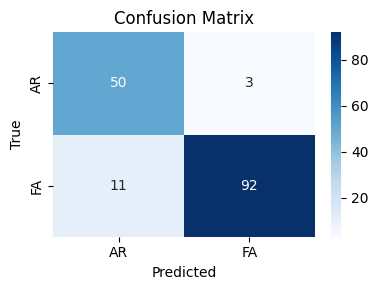


training accuracy :  [0.97580645 0.968      0.976      0.976      0.976     ] avg: 0.9743612903225806
test accuracy :  [0.84375    0.90322581 0.93548387 0.93548387 0.93548387] avg: 0.9106854838709678

Misclassified:
                            id category
12        COND0001363-RSp0641     LCFA
23     COND0000306-SSIG_07966     LCFA
51     COND0002581-QKF54435.2     SCFA
55           COND0001230-sln9     MCFA
69          COND0002661-tsk10     SCFA
91     COND0001574-ATY72525.1     SCFA
100  COND0001844-RBRH_RS16800     MCFA
117    COND0002654-UHJ79953.1     LCFA
129      COND0001599-I35_4189     MCFA
135   COND0002467-YWY_RS21605     SCFA
142          COND0002125-frsA     SCFA
146          COND0002373-bnvO       AR
149     COND0001825-XNC2_2611       AR
152      COND0000460-VV2_0844       AR


/var/folders/rt/kl_lws993wvbgr3lkh7w2g8r0000gn/T/ipykernel_58307/4285910915.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  misclassified = ml_df[y != cvs_pred]


In [37]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, ARDRegression
from sklearn.model_selection import cross_val_predict, cross_val_score
import pandas as pd
from sklearn.metrics import confusion_matrix

i = 1
y = ml_df['category_simple']
X = ml_df.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)
X, y = shuffle(X, y,random_state=i)

ridge = RidgeClassifier(class_weight='balanced', alpha=90, solver='svd')

cvs = cross_val_score(ridge, X, y, cv=5)
cvs_pred = cross_val_predict(ridge, X, y, cv=5)
print(cvs, avg(cvs))
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y, cvs_pred, labels=["AR", "FA"]), annot=True, fmt='d', cmap='Blues', xticklabels=['AR', 'FA'], yticklabels=['AR', 'FA'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
cvoutput = cross_validate(ridge, X, y, cv=5, return_train_score=True)
print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

misclassified = ml_df[y != cvs_pred]
print('\nMisclassified:\n',misclassified.iloc[:,:2])

[0.8125     0.74193548 0.83870968 0.77419355 0.87096774] 0.8076612903225806


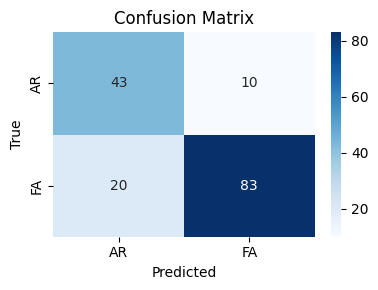


training accuracy :  [0.90322581 0.904      0.92       0.904      0.912     ] avg: 0.9086451612903226
test accuracy :  [0.8125     0.74193548 0.83870968 0.77419355 0.87096774] avg: 0.8076612903225806

Misclassified:
                                                     id category
2                                     COND0000445-tioR       AR
12                                 COND0001363-RSp0641     LCFA
23                              COND0000306-SSIG_07966     LCFA
33                                    COND0000415-qui7       AR
49                             COND0002414-JJO56_07700       AR
51                              COND0002581-QKF54435.2     SCFA
55                                    COND0001230-sln9     MCFA
56                                   COND0001297-cal17       AR
59                                    COND0000341-endA     LCFA
67                                    COND0001657-lesA     MCFA
69                                   COND0002661-tsk10     SCFA
70            

/var/folders/rt/kl_lws993wvbgr3lkh7w2g8r0000gn/T/ipykernel_58307/3528747141.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  misclassified = ml_df[y != cvs_pred]


In [38]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, ARDRegression
from sklearn.model_selection import cross_val_predict, cross_val_score
import pandas as pd
from sklearn.metrics import confusion_matrix

i = 1
y = ml_df['category_simple']
X = ml_df.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)
X, y = shuffle(X, y, random_state=i)

lreg = LogisticRegression(solver='liblinear', class_weight='balanced', penalty='l1', C=0.1)

cvs = cross_val_score(lreg, X, y, cv=5)
cvs_pred = cross_val_predict(lreg, X, y, cv=5)
print(cvs, avg(cvs))
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y, cvs_pred, labels=["AR", "FA"]), annot=True, fmt='d', cmap='Blues', xticklabels=['AR', 'FA'], yticklabels=['AR', 'FA'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
cvoutput = cross_validate(lreg, X, y, cv=5, return_train_score=True)
print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

misclassified = ml_df[y != cvs_pred]
print('\nMisclassified:\n',misclassified.iloc[:,:2])